## Kaggle Notebook

You can view the complete version of this project on Kaggle:

👉 [View on Kaggle](https://www.kaggle.com/code/mrtaiech/can-simple-knn-detect-cancer)

### Intuition 

#### You are the average of the five people you spend the most time with.  
##### — Jim Rohn

### KNN Working (2D Example)

Let's suppose you have a 2D dataset with:

- Input features: CGPA, IQ  
- Output: Placement (Yes/No)

For **K = 3**, you consider the 3 nearest neighbors.

First, take a query point (a new student). Then:

1. Calculate the **Euclidean distance** between the query point and all training points.  
   - If there are 100 training points, you compute 100 distances.

2. Sort all the distances in **ascending order**.  
   - The closest points come first.

3. Select the **top 3 nearest neighbors**.

4. Perform **majority voting**:  
   - Ask the class (Yes/No) of each neighbor  
   - The majority class becomes the prediction for the query point  

---

### Extension to Higher Dimensions

The beauty of KNN is that it is not limited to 2D data.

- Each student can be represented as a **vector** with multiple features  
- The query point is also a vector  

Steps remain the same:

1. Compute distance between vectors  
2. Select the K nearest vectors  
3. Perform majority voting  

The majority class of these K vectors is the final prediction.

## Kaggle Notebook

You can view the complete version of this project on Kaggle:

👉 [View on Kaggle](https://www.kaggle.com/code/mrtaiech/can-simple-knn-detect-cancer)

## How to select K? 

## Choosing the Value of K in KNN

The choice of K depends largely on the **data and problem**.

---

### 1. Heuristic Approach

Some commonly used rules:

- Start with small values like **K = 3, 5, 7**
- A common rule of thumb:
  
  K ≈ √N  
  (where N = number of data points)

This gives a reasonable starting point, but not always optimal.

---

### 2. Experimental Approach (Recommended)

The best way to choose K is through experimentation:

- Train the model with different K values  
- Evaluate performance (accuracy, etc.)  
- Plot **Accuracy vs K**  
- Select the K with the best performance  

---

### Why Avoid Even Values of K?

In **binary classification**:

- Even K can lead to **ties**  
  (e.g., 2 neighbors → 1 Yes, 1 No)

- Odd K avoids this issue by ensuring a **clear majority vote**

---



> There is no fixed best K — it always depends on the dataset.

Choosing K is a balance between:
- Overfitting (small K)  
- Underfitting (large K)

#### Cross-Validation for Choosing K in KNN

Cross-validation helps us select the best value of K in a more reliable way.

---

### Process

- Train multiple KNN models with different values of K  
- Evaluate each model’s performance  
- Compare their accuracy scores  

---

### Simple Approach

- Train different KNN models on the training data  
- Test all models on the testing data  
- Select the model with the **highest accuracy**

---

### NOte

Instead of relying on a single choice, we compare multiple models and choose the one that performs best.

# Decision Surface 

#### Decision Surface Visualization

The decision surface is a technique used to visualize how a classification model separates different classes in the feature space.

---

### What It Does

- Shows how the model divides the input space into regions  
- Each region corresponds to a predicted class  
- Helps us understand how the model makes decisions  

---

### Example

Consider a dataset with:

- Features: **CGPA, IQ**  
- Output: **Binary (0 or 1)**  

Each data point is plotted in a 2D space:
- Points of different classes are shown in different colors (e.g., blue and green)  

---

### Decision Surface

- The model creates boundaries that divide the space into regions  
- Each region represents a predicted class (0 or 1)  
- These regions together form the **decision surface**  

---

### Query Point

- A new data point (query point) is placed in this space  
- The region in which it falls determines its predicted class  

---

### Insight

Decision surface visualization helps us:

- Understand how the model separates classes  
- Identify overfitting or underfitting  
- Build intuition about model behavior  

---

### Note

This technique is mainly used for **2D data visualization** and is helpful for learning and interpretation.

#### How Decision Surface Visualization Works

---

### Step-by-Step Process

1. **Plot Training Data**
   - Plot the training points in a 2D space (e.g., CGPA vs IQ)  
   - Different classes are shown using different colors  

---

2. **Find Feature Ranges**
   - Determine the range of values for both axes:
     - X-axis (feature 1)  
     - Y-axis (feature 2)  

---

3. **Create a Mesh Grid**
   - Generate a grid of points covering the entire feature space using NumPy  
   - Each point in the grid represents a possible input  

---

4. **Train the KNN Model**
   - Fit the KNN model using the training data  

---

5. **Predict on Grid Points**
   - Pass all mesh grid points into the trained KNN model  
   - The model predicts a class for each point:
     - 1 → encoded as one color (e.g., blue)  
     - 0 → encoded as another color (e.g., green)  

---

6. **Plot the Decision Surface**
   - Color each grid point based on its predicted class  
   - These colored regions form the **decision surface**  

---

### Final Idea

The decision surface shows how the model classifies the entire space, not just the training points.

A new (query) point is classified based on the region it falls into.

#### Python Libraries for Decision Surface Visualization

To create decision surface visualizations, we commonly use:

- **NumPy** → for numerical operations and mesh grid creation  
- **Matplotlib** → for plotting the surface and data points  
- **scikit-learn (sklearn)** → for building the KNN model  

---

### How It Works

- NumPy creates a grid of points covering the feature space  
- The trained model predicts the class for each grid point  
- Matplotlib visualizes these predictions as colored regions  

---

### Sample Code

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification

# Generate sample 2D data
X, y = make_classification(n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

# Train KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)

# Create mesh grid
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision surface
plt.contourf(xx, yy, Z, alpha=0.4)

# Plot training points
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

plt.title("KNN Decision Surface")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Overfitting and Underfitting in KNN

#### Intuition: Overfitting vs Underfitting in KNN

When a new query point comes, KNN looks at its nearest neighbors and assigns the class based on majority voting.

---

### Overfitting (Small K)

- If **K is very small (e.g., K = 1)**  
- The model depends heavily on very few neighbors  
- Predictions become sensitive to noise  

👉 This leads to **high variance** → **overfitting**

---

### Underfitting (Large K)

- Maximum possible value of **K = N (total data points)**  
- The model considers all points in the dataset  
- Prediction becomes the **majority class of the dataset**  

👉 The model becomes too simple → **underfitting**

---

### Key Insight

- Small K → High variance → Overfitting  
- Large K → High bias → Underfitting  

Understanding overfitting and underfitting is crucial for building a reliable KNN model.

---

### What is Overfitting?

Overfitting occurs when the model learns the training data too closely, including noise.

#### In KNN:
- Happens when **K is very small (e.g., K = 1)**  
- The model focuses on individual data points  
- Decision boundary becomes **highly irregular and complex**

#### Result:
- Very high training accuracy  
- Poor performance on unseen (test) data  

---

### What is Underfitting?

Underfitting occurs when the model is too simple to capture the underlying pattern.

#### In KNN:
- Happens when **K is very large (e.g., K = 15, 20)**  
- The model averages too many points  
- Decision boundary becomes **overly smooth**

#### Result:
- Poor performance on both training and testing data  

---

### Key Difference

| Concept       | K Value      | Behavior                     |
|--------------|-------------|------------------------------|
| Overfitting  | Small K     | Complex, noisy boundary      |
| Underfitting | Large K     | Smooth, overly simple        |

---

### Visual Intuition

- **Small K → Sharp, jagged boundaries → memorization**  
- **Large K → Smooth boundaries → generalization (but too much smoothing is bad)**  

---

### Goal

Choose a value of K that:

- Avoids overfitting  
- Avoids underfitting  
- Provides the best balance (**bias vs variance tradeoff**)  

---

### Final Insight

> The performance of KNN depends heavily on the choice of K, making it essential to tune this parameter carefully.

## Example 

In [22]:
import pandas as pd

df = pd.read_csv("glass.csv")
df.sample(23)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
160,1.51832,13.33,3.34,1.54,72.14,0.56,8.99,0.00,0.00,3
30,1.51768,12.65,3.56,1.30,73.08,0.61,8.69,0.00,0.14,1
124,1.52177,13.20,3.68,1.15,72.75,0.54,8.52,0.00,0.00,2
192,1.51623,14.20,0.00,2.79,73.46,0.04,9.04,0.40,0.09,7
195,1.51545,14.14,0.00,2.68,73.39,0.08,9.07,0.61,0.05,7
18,1.51911,13.90,3.73,1.18,72.12,0.06,8.89,0.00,0.00,1
166,1.52151,11.03,1.71,1.56,73.44,0.58,11.62,0.00,0.00,5
150,1.51665,13.14,3.45,1.76,72.48,0.60,8.38,0.00,0.17,3
179,1.51852,14.09,2.19,1.66,72.67,0.00,9.32,0.00,0.00,6
90,1.51841,12.93,3.74,1.11,72.28,0.64,8.96,0.00,0.22,2


In [24]:
# shape
df.shape

# info
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

## Dataset Overview

The dataset contains **214 samples** with **10 columns**.

---

### Feature Information

- **9 numerical features**:
  - RI, Na, Mg, Al, Si, K, Ca, Ba, Fe  

- **1 target variable**:
  - Type (Glass category)

---

### Data Quality

- No missing values in any column  
- All features are numerical  
- Dataset is already clean and ready for modeling  

---

### Insight

This dataset requires **minimal preprocessing**, making it ideal for applying algorithms like KNN.

However, since KNN is distance-based, **feature scaling is still essential**.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('Type', axis=1)
y = df['Type']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
X_train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
79,1.51590,12.82,3.52,1.90,72.86,0.69,7.97,0.00,0.00
161,1.51934,13.64,3.54,0.75,72.65,0.16,8.89,0.15,0.24
109,1.51818,13.72,0.00,0.56,74.45,0.00,10.99,0.00,0.00
127,1.52081,13.78,2.28,1.43,71.99,0.49,9.85,0.00,0.17
95,1.51860,13.36,3.43,1.43,72.26,0.51,8.60,0.00,0.00


In [28]:
scaler = StandardScaler()

In [29]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
X_train[:7]

array([[-0.84623746, -0.74467528,  0.52636164,  1.01287057,  0.345884  ,
         0.33930631, -0.68807645, -0.33761134, -0.60110996],
       [ 0.28077633,  0.33413832,  0.54088841, -1.40290866,  0.07169648,
        -0.609516  , -0.03692037, -0.04564469,  1.78472688],
       [-0.0992632 ,  0.43938842, -2.03034913, -1.8020374 ,  2.42187517,
        -0.89595292,  1.44941417, -0.33761134, -0.60110996],
       [ 0.76237816,  0.518326  , -0.37429784,  0.0255521 , -0.7900357 ,
        -0.01873984,  0.64254685, -0.33761134,  1.0888578 ],
       [ 0.03833732, -0.03423706,  0.4609912 ,  0.0255521 , -0.4375089 ,
         0.01706477, -0.24217609, -0.33761134, -0.60110996],
       [ 0.71978752,  0.21573194, -0.51230211,  0.52971472, -0.54196128,
         0.05286939,  0.44436891,  0.18792863,  1.0888578 ],
       [-0.13857763, -0.50786254,  0.72973636, -0.70968506,  0.62007151,
         0.10657631, -0.39788733, -0.33761134,  0.59180846]])

In [35]:
X_test[:7]

array([[-0.30566398, -0.50786254,  0.5844687 , -0.12149533,  0.51561912,
         0.12447862, -0.38373176, -0.33761134,  0.49239859],
       [-0.39739766,  1.72870223, -2.03034913,  1.93716871,  0.89425902,
        -0.89595292,  0.00554633,  0.94704191, -0.60110996],
       [ 0.99498856, -0.44208122,  0.62078562, -1.15082735, -0.48973509,
        -0.55580907,  0.64254685, -0.33761134,  1.0888578 ],
       [-0.80692302,  1.92604619, -2.03034913,  2.02119582,  0.89425902,
        -0.89595292, -0.12893155,  0.90811303,  0.29357885],
       [-0.45964552,  0.43938842,  0.64257577,  0.82380959, -0.69863986,
         0.24979477, -0.7517765 , -0.33761134, -0.60110996],
       [ 2.91811965, -3.11280269, -2.03034913, -1.40290866,  0.63312806,
        -0.89595292,  4.25929423, -0.33761134, -0.60110996],
       [-0.28600676, -0.75783155,  0.54088841, -0.39458342,  0.84203283,
         0.14238093, -0.39080954, -0.33761134, -0.60110996]])

In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (171, 9)
X_test: (43, 9)
y_train: (171,)
y_test: (43,)


## Selecting the Optimal Value of K

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [43]:
scores = []  

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

In [45]:
print(len(scores)) 

20


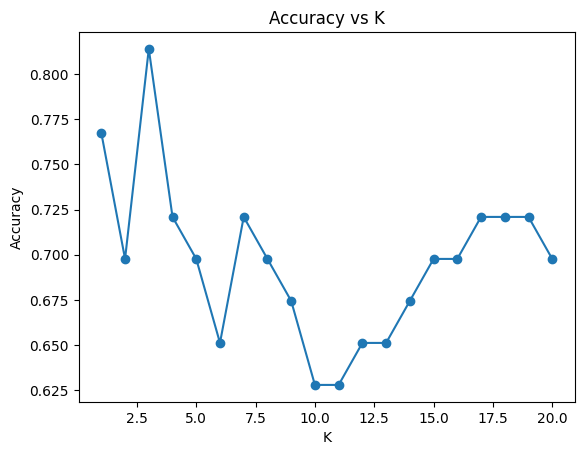

In [46]:
plt.plot(range(1, 21), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()



### Key Observations

- The highest accuracy (~81%) is achieved at **K = 3**  
- For very small K (like 1), accuracy is slightly lower  
- Accuracy drops significantly around K = 9–11  
- For larger K values, accuracy stabilizes but does not improve  

---

### Insight

- **K = 3** gives the best performance for this dataset  
- Small K values capture local patterns effectively  
- Larger K values oversimplify the model and reduce accuracy  

---

### Understanding Behavior

- **K = 1–3** → More flexible → captures detailed patterns  
- **K = 9+** → Too smooth → loses important distinctions  

---

### Conclusion

> For this dataset, **K = 3** provides the best balance between model complexity and generalization.

> ## Note: Due to small dataset size, KNN performance may vary significantly with small changes in K.

## Visualizing Overfitting and Underfitting using Decision Surfaces


Observe how the decision boundary changes with:

- Small K → Overfitting  
- Optimal K → Balanced  
- Large K → Underfitting  

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [48]:
# Take only 2 features for visualization
X_vis = df.drop('Type', axis=1).iloc[:, :2]
y_vis = df['Type']

In [49]:
scaler = StandardScaler()
X_vis = scaler.fit_transform(X_vis)

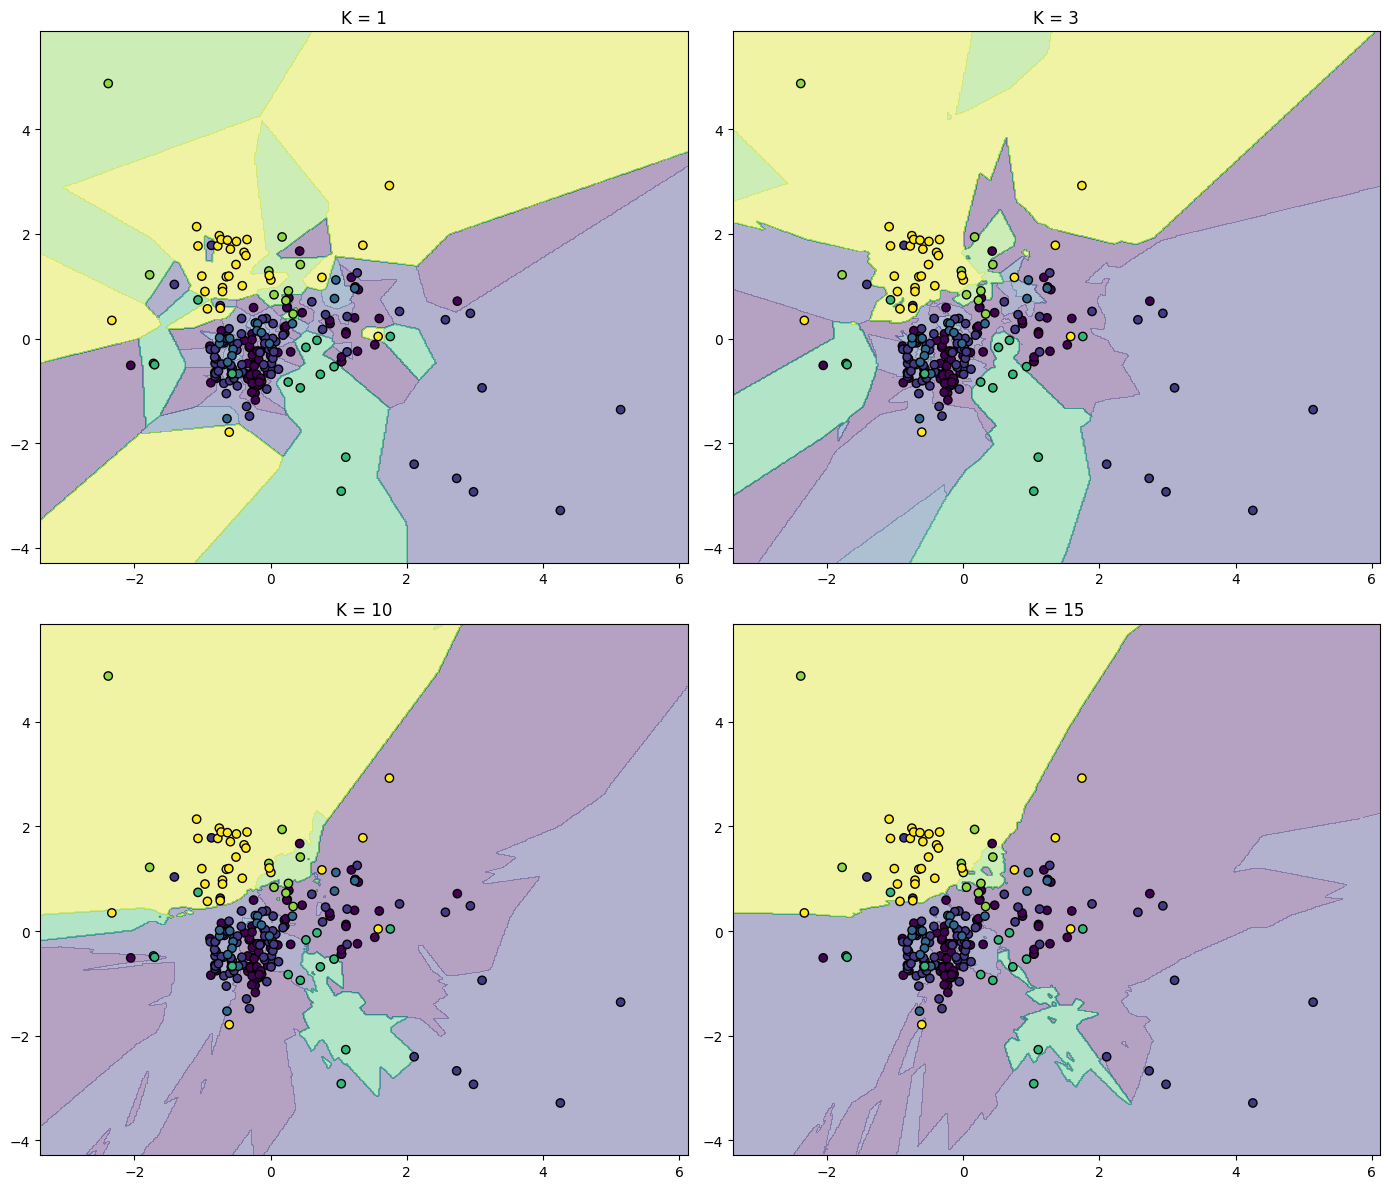

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

k_values = [1, 3, 10, 15]

for idx, k in enumerate(k_values):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_vis, y_vis)

    h = 0.02
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.4)
    axes[idx].scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolor='k')
    axes[idx].set_title(f"K = {k}")

plt.tight_layout()
plt.show()

## Limitation of KNN 

While KNN is simple and effective, it has several important limitations.

---

### 1. Computationally Expensive

- KNN does not have a training phase  
- It stores all training data  
- During prediction, it computes distance from all points  

>  Slow for large datasets  

---

### 2. Sensitive to Feature Scaling

- KNN relies on distance calculations  
- Features with larger values dominate  

>  Requires proper feature scaling  

---

### 3. Curse of Dimensionality

- As the number of features increases:
  - Distance becomes less meaningful  
  - Neighbors become harder to distinguish  

> Performance degrades in high-dimensional data  

---

### 4. Choosing K is Not Straightforward

- Small K → overfitting  
- Large K → underfitting  

> Requires experimentation  

---

### 5. Sensitive to Noise

- Noisy data can affect nearest neighbors  
- Especially problematic when K is small  

---

### 6. Memory Intensive

- Stores entire dataset  
- Requires more memory compared to other models  

---
### 7. Sensitive to Imbalanced Data

- If one class has significantly more data points than others:
  - It can dominate the nearest neighbors  
  - The model becomes biased toward the majority class  

> This leads to poor performance on minority classes
  

____
 


> KNN is simple and powerful for small, well-structured datasets, but struggles with large-scale and high-dimensional data.

## When to Use KNN vs When NOT to Use It

---

### When to Use KNN

KNN works well in the following scenarios:

- **Small to medium-sized datasets**  
  - Since KNN is slow for large datasets  

- **Low-dimensional data**  
  - Fewer features → better distance calculation  

- **Well-scaled data**  
  - Features are normalized or standardized  

- **Clear class separation**  
  - Classes are distinguishable in feature space  

- **Simple baseline model**  
  - Good starting point before trying complex models  

---

### When NOT to Use KNN

Avoid KNN in the following cases:

- **Large datasets**
  - Prediction becomes very slow  

- **High-dimensional data**
  - Distance becomes less meaningful (curse of dimensionality)  

- **Imbalanced datasets**
  - Majority class dominates predictions  

- **Noisy data**
  - Small K becomes unstable  

- **Real-time prediction systems**
  - High latency due to distance calculations  

---


> KNN is a simple and powerful algorithm, but its effectiveness depends heavily on the nature of the data.

Choosing the right algorithm is as important as tuning the model.